In [2]:
# ==========================================
# ESTIMASI NILAI PI DENGAN METODE MONTE CARLO
# SERIAL VERSION
# ==========================================

import random
import time
import math


# ==========================================
# FUNGSI MENGHITUNG PI
# ==========================================
def calculate_pi_serial(num_samples):

    inside_circle = 0

    # Perulangan sebanyak jumlah sample
    for _ in range(num_samples):

        # Generate titik random
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        # Cek apakah titik berada di dalam lingkaran
        if x**2 + y**2 <= 1:
            inside_circle += 1

    # Rumus estimasi PI
    pi_estimate = 4 * inside_circle / num_samples

    return pi_estimate


# ==========================================
# PROGRAM UTAMA
# ==========================================
if __name__ == "__main__":

    # Jumlah titik random
    num_samples = 10_000_000

    # Mulai hitung waktu
    start_time = time.time()

    # Hitung estimasi PI
    pi_est = calculate_pi_serial(num_samples)

    # Selesai hitung waktu
    end_time = time.time()

    # ==========================================
    # OUTPUT
    # ==========================================
    print("===== HASIL ESTIMASI PI =====")
    print(f"Estimasi π     : {pi_est}")
    print(f"Nilai asli π   : {math.pi}")
    print(f"Error          : {abs(pi_est - math.pi)}")
    print(f"Waktu eksekusi : {end_time - start_time:.4f} detik")

===== HASIL ESTIMASI PI =====
Estimasi π     : 3.1429732
Nilai asli π   : 3.141592653589793
Error          : 0.0013805464102070175
Waktu eksekusi : 4.5471 detik


In [4]:
import multiprocessing
import random
import time
import math


def monte_carlo_chunk(chunk_size):

    inside = 0

    for _ in range(chunk_size):

        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            inside += 1

    return inside


def calculate_pi_parallel(num_samples, num_processes):

    chunk_size = num_samples // num_processes

    with multiprocessing.Pool(processes=num_processes) as pool:

        results = pool.map(
            monte_carlo_chunk,
            [chunk_size] * num_processes
        )

    total_inside = sum(results)

    pi_estimate = 4 * total_inside / (
        chunk_size * num_processes
    )

    return pi_estimate


# ===================================
# MAIN PROGRAM
# ===================================
if __name__ == "__main__":

    multiprocessing.set_start_method(
        "fork",
        force=True
    )

    num_samples = 1_000_000

    for num_procs in [1, 2, 4, 8, 16, 32]:

        start_time = time.time()

        pi_est = calculate_pi_parallel(
            num_samples,
            num_procs
        )

        end_time = time.time()

        print(f"\nProses: {num_procs}")
        print(f"Estimasi π : {pi_est}")
        print(f"Waktu      : {end_time - start_time:.4f} detik")


Proses: 1
Estimasi π : 3.14028
Waktu      : 0.5363 detik

Proses: 2
Estimasi π : 3.143012
Waktu      : 0.3321 detik

Proses: 4
Estimasi π : 3.143404
Waktu      : 0.2861 detik

Proses: 8
Estimasi π : 3.14246
Waktu      : 0.3099 detik

Proses: 16
Estimasi π : 3.141868
Waktu      : 0.3720 detik

Proses: 32
Estimasi π : 3.140428
Waktu      : 0.5553 detik


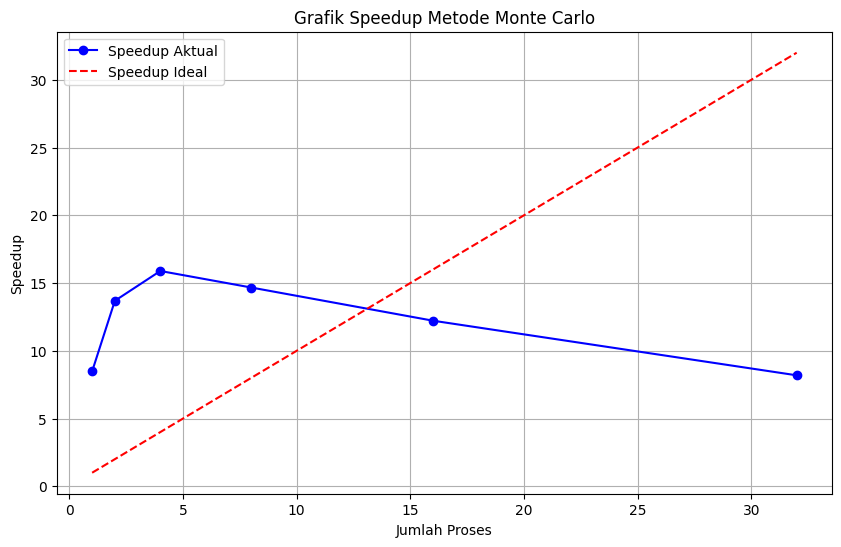

In [5]:
import matplotlib.pyplot as plt

# Data dari hasil pengujian
process_counts = [1, 2, 4, 8, 16, 32]

# Hasil speedup berdasarkan data kamu
speedups = [8.48, 13.69, 15.89, 14.67, 12.22, 8.19]

# Grafik
plt.figure(figsize=(10, 6))

# Grafik speedup aktual
plt.plot(process_counts, speedups, 'bo-', label='Speedup Aktual')

# Grafik speedup ideal
plt.plot(process_counts, process_counts, 'r--', label='Speedup Ideal')

# Label dan judul
plt.xlabel('Jumlah Proses')
plt.ylabel('Speedup')
plt.title('Grafik Speedup Metode Monte Carlo')

# Legend dan grid
plt.legend()
plt.grid(True)

# Simpan gambar
plt.savefig('speedup_analysis.png')

# Tampilkan grafik
plt.show()